# Практика: Наивный Байес с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите датасет для задачи классификации;
2. подготовите данные для обучения;
3. реализуете **Гауссовский Наивный Байес с нуля**:
   - оценку априорных вероятностей классов,
   - оценку параметров (среднее и дисперсия) по каждому признаку,
   - вычисление правдоподобия (likelihood),
   - классификацию по правилу Байеса;
4. обучите свою модель;
5. сравните её качество и параметры с реализацией из `scikit-learn`;
6. проверите, что происходит при нарушении допущения о независимости признаков.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Iris` из `sklearn.datasets`:
- задача **многоклассовой классификации** (3 класса);
- признаки числовые, непрерывные;
- датасет хорошо подходит для изучения Гауссовского Наивного Байеса.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - в чём главное допущение Наивного Байеса и когда оно нарушается;
   - когда Наивный Байес предпочтительнее логистической регрессии.

## Коротко о теории

### 1. Теорема Байеса
Для классификации нам нужно найти наиболее вероятный класс \(c\) при данных признаках \(x\):


$$P(c \mid x) = \frac{P(x \mid c) \cdot P(c)}{P(x)}$$

Так как \(P(x)\) одинаково для всех классов, достаточно максимизировать числитель:

$$\hat{c} = \arg\max_{c} \; P(x \mid c) \cdot P(c)$$


### 2. Наивное допущение о независимости
«Наивным» Байес называется потому, что предполагает условную **независимость** признаков:

$$P(x \mid c) = \prod_{j=1}^{d} P(x_j \mid c)$$

Это сильное допущение, которое редко выполняется на практике, но модель всё равно часто работает хорошо.

### 3. Гауссовское допущение
Для непрерывных признаков предполагаем, что каждый признак имеет нормальное распределение внутри класса:

$$P(x_j \mid c) = \frac{1}{\sqrt{2\pi\sigma_{cj}^2}} \exp\!\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)$$

### 4. Логарифм для численной стабильности
Произведение многих вероятностей быстро стремится к нулю. На практике считаем **логарифм**:

$$\log P(c \mid x) \propto \log P(c) + \sum_{j=1}^{d} \log P(x_j \mid c)$$

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.naive_bayes.GaussianNB`:
- accuracy,
- precision (macro),
- recall (macro),
- f1 (macro).

### 6. Априорные вероятности
Оцениваются по частоте встречаемости каждого класса в обучающей выборке:

$$P(c) = \frac{n_c}{n}$$


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [4]:
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Классы:", data.target_names)
display(X.head())
display(y.value_counts().rename(index=dict(enumerate(data.target_names))))

Размер X: (150, 4)
Классы: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Пропуски по признакам:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


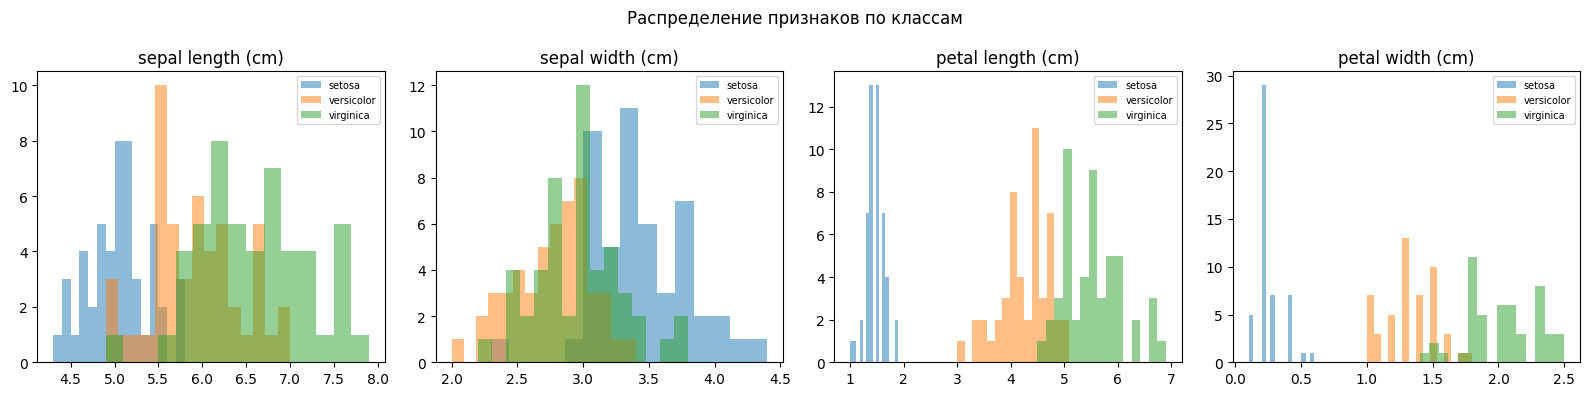

In [5]:
print("Пропуски по признакам:")
display(X.isna().sum())

print("\nБазовая статистика:")
display(X.describe().T)

# Визуализируем распределение одного признака по классам
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(X.columns):
    for cls in range(3):
        axes[i].hist(X[col][y == cls], alpha=0.5, label=data.target_names[cls], bins=15)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
plt.suptitle("Распределение признаков по классам")
plt.tight_layout()
plt.show()


## Шаг 1. Разделение данных

Ниже нужно:
1. разбить выборку на train и test;
2. получить `X_train`, `X_test`, `y_train`, `y_test`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`.
- **Стандартизация здесь не нужна** — Наивный Байес сам оценивает параметры распределения по каждому признаку.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Распределение классов в train:", pd.Series(y_train).value_counts().to_dict())

Train shape: (120, 4)
Test shape: (30, 4)
Распределение классов в train: {1: 41, 0: 40, 2: 39}


## Шаг 2. Оцениваем априорные вероятности классов

Напишите функцию `compute_priors(y)`, которая возвращает словарь `{класс: P(класс)}`.

Проверка:
- сумма всех вероятностей должна быть равна `1.0`.

In [7]:
def compute_priors(y):
    value, counts = np.unique(y, return_counts=True)
    return dict(zip(value, counts/len(y)))

priors = compute_priors(y_train.values)
print("Априорные вероятности:", priors)
print("Сумма:", sum(priors.values()))


Априорные вероятности: {np.int64(0): np.float64(0.3333333333333333), np.int64(1): np.float64(0.3416666666666667), np.int64(2): np.float64(0.325)}
Сумма: 1.0


## Шаг 3. Оцениваем параметры распределений по каждому классу

Для Гауссовского Наивного Байеса нужно по каждому классу и каждому признаку оценить:
- **среднее** `mu[c, j]` — среднее значение признака \(j\) в классе \(c\),
- **дисперсию** `var[c, j]` — дисперсию признака \(j\) в классе \(c\).

Напишите функцию `fit_gaussian_params(X, y)`, которая возвращает два массива: `means` и `variances` формы `(n_classes, n_features)`.

Подсказка:
- используйте `np.var(...)` — это **несмещённую** дисперсию лучше считать с `ddof=0` (по умолчанию).

In [8]:
def fit_gaussian_params(X, y):

    classes = np.unique(y)  
    n_classes = len(classes)
    n_features = X.shape[1]

    means = np.zeros((n_classes, n_features))
    variances = np.zeros((n_classes, n_features))

    for i, c in enumerate(classes):
        Xc = X[y==c]
        means[i] = Xc.mean(axis=0)
        variances[i] = Xc.var(axis=0, ddof=0)

    return means, variances


X_train_np = X_train.values
y_train_np = y_train.values

means, variances = fit_gaussian_params(X_train_np, y_train_np)
print("means shape:", means.shape)
print("\nМатрица средних (класс x признак):")
display(pd.DataFrame(means, columns=data.feature_names, index=data.target_names).round(3))
print("\nМатрица дисперсий (класс x признак):")
display(pd.DataFrame(variances, columns=data.feature_names, index=data.target_names).round(4))

means shape: (3, 4)

Матрица средних (класс x признак):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.990,3.452,1.450,0.245
versicolor,5.920,2.771,4.241,1.322
virginica,6.533,2.967,5.521,2.000



Матрица дисперсий (класс x признак):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.1239,0.1525,0.0330,0.0110
versicolor,0.2869,0.1001,0.2258,0.0412
virginica,0.4166,0.0991,0.2857,0.0821


## Шаг 4. Вычисляем log-likelihood

Напишите функцию `gaussian_log_likelihood(x, mean, var)`, которая возвращает логарифм плотности нормального распределения:

$\log P(x_j \mid c) = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{(x_j - \mu)^2}{2\sigma^2}$

Подсказка:
- `var` может быть очень маленьким — добавьте небольшую константу `eps=1e-9` к дисперсии во избежание деления на ноль.

In [9]:
import numpy as np

def gaussian_log_likelihood(x, mean, var, eps=1e-9):

    var_smoothed = var + eps
    
    term1 = -0.5 * np.log(2 * np.pi * var_smoothed)
    term2 = -((x - mean)**2) / (2 * var_smoothed)
    
    log_probs_per_feature = term1 + term2
    
    log_likelihood = np.sum(log_probs_per_feature)
    
    return log_likelihood

test_x = X_train_np[0]
ll = gaussian_log_likelihood(test_x, means[0], variances[0])
print("Log-likelihood для первого объекта (класс 0):", ll)

Log-likelihood для первого объекта (класс 0): -1.5751797834326244


## Шаг 5. Собираем классификатор в класс

Допишите методы:
- `fit` — оценить прайоры, средние и дисперсии;
- `predict_log_proba` — вычислить логарифм апостериорной вероятности для каждого класса;
- `predict` — вернуть класс с наибольшей апостериорной вероятностью.

Требования:
- использовать логарифмы для численной стабильности;
- метод должен работать на `numpy`-массивах.

In [10]:
class MyGaussianNB:
    def __init__(self, var_smoothing=1e-9):
        self.classes_ = None
        self.log_priors_ = None  # логарифмы априорных вероятностей
        self.means_ = None       # (n_classes, n_features)
        self.variances_ = None   # (n_classes, n_features)
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_) #количество уникальных значений
        n_features = X.shape[1] #количество признаков
        n_samples = len(y) #количество объектов

        self.log_priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))
        self.variances_ = np.zeros((n_classes, n_features))

        for i, c in enumerate(self.classes_):
            Xc = X[y==c]
            prior = len(Xc) / n_samples
            self.log_priors_[i] = np.log(prior)
        
        self.means_, self.variances_ = fit_gaussian_params(X, y)

        max_variances = np.max(self.variances_)
        self.variances_ += self.var_smoothing * max_variances

        return self

    def predict_log_proba(self, X):

        n_samples = X.shape[0] #количество объектов
        n_classes = len(self.classes_) #количсетво классов
        log_proba = np.zeros((n_samples, n_classes))

        for i in range(n_samples):
            for c in range(n_classes):
                log_priors = self.log_priors_[c]
                log_likelihood = gaussian_log_likelihood(
                    x=X[i],
                    mean = self.means_[c],
                    var=self.variances_[c]
                )

                log_proba[i, c] = log_priors + log_likelihood

        return log_proba

    def predict(self, X):
        log_proba = self.predict_log_proba(X)
        pred_indx = np.argmax(log_proba, axis=1)
        preds = self.classes_[pred_indx]
        return preds
    
    def predict_proba(self, X):

        log_proba = self.predict_log_proba(X)
        
        log_proba_max = np.max(log_proba, axis=1, keepdims=True)
        log_proba_stable = log_proba - log_proba_max
        
        proba = np.exp(log_proba_stable)
        
        proba_sum = np.sum(proba, axis=1, keepdims=True)
        proba = proba / proba_sum
        
        return proba

## Шаг 6. Обучаем свою модель

Обучите `MyGaussianNB` и убедитесь, что:
- модель обучилась без ошибок;
- параметры имеют ожидаемую форму.

In [11]:
my_model = MyGaussianNB(var_smoothing=1e-9)

my_model.fit(X_train_np, y_train_np)

print("Классы:", my_model.classes_)
print("Log-прайоры:", my_model.log_priors_)
print("Форма means_:", my_model.means_.shape)

Классы: [0 1 2]
Log-прайоры: [-1.09861229 -1.07391968 -1.1239301 ]
Форма means_: (3, 4)


## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте метрики на тестовой выборке:
- accuracy,
- precision (macro),
- recall (macro),
- f1 (macro).

In [12]:
X_test_np = X_test.values
y_test_np = y_test.values

my_pred_test = my_model.predict(X_test_np)

my_metrics = {
    "accuracy": accuracy_score(y_test_np, my_pred_test),
    "precision_macro": precision_score(y_test_np, my_pred_test, average='macro', zero_division=0),
    "recall_macro": recall_score(y_test_np, my_pred_test, average='macro', zero_division=0),
    "f1_macro": f1_score(y_test_np, my_pred_test, average='macro', zero_division=0),
}

pd.Series(my_metrics).round(4)

accuracy           1.0
precision_macro    1.0
recall_macro       1.0
f1_macro           1.0
dtype: float64

In [13]:
print("Влияние var_smoothing на метрики (без него):")

model = MyGaussianNB(var_smoothing=0)
model.fit(X_train_np, y_train_np)
preds = model.predict(X_test_np)

metrics = {
    "accuracy": accuracy_score(y_test_np, preds),
    "precision_macro": precision_score(y_test_np, preds, average='macro', zero_division=0),
    "recall_macro": recall_score(y_test_np, preds, average='macro', zero_division=0),
    "f1_macro": f1_score(y_test_np, preds, average='macro', zero_division=0),
}

pd.Series(metrics).round(4)

Влияние var_smoothing на метрики (без него):


accuracy           1.0
precision_macro    1.0
recall_macro       1.0
f1_macro           1.0
dtype: float64

In [14]:
proba = my_model.predict_proba(X_test_np)
print("Пример вероятностей для первых 3 объектов:")
print(proba[:3])

print("\nПроверка, что сумма вероятностей = 1:")
print(f"Суммы вероятностей: {proba.sum(axis=1)[:3]}")

preds_from_proba = my_model.classes_[np.argmax(proba, axis=1)]

print(f"\nПредсказания совпадают: {np.allclose(preds_from_proba, my_pred_test)}")

Пример вероятностей для первых 3 объектов:
[[5.97319052e-090 9.95635767e-001 4.36423263e-003]
 [1.00000000e+000 4.96157794e-014 6.54922006e-021]
 [7.31852949e-290 4.92947345e-012 1.00000000e+000]]

Проверка, что сумма вероятностей = 1:
Суммы вероятностей: [1. 1. 1.]

Предсказания совпадают: True


## Шаг 8. Confusion matrix

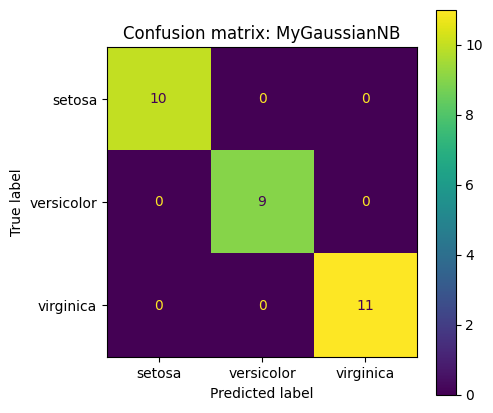

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_np, my_pred_test,
    display_labels=data.target_names,
    ax=ax
)
plt.title("Confusion matrix: MyGaussianNB")
plt.show()

print(classification_report(y_test_np, my_pred_test, target_names=data.target_names))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечный `GaussianNB` и сравните его с вашей реализацией.

Рекомендации:
- используйте `GaussianNB()` без дополнительных параметров;
- обучайте на тех же данных `X_train_np`.

In [16]:
sk_model = GaussianNB()

sk_model.fit(X_train_np, y_train_np)

sk_pred_test = sk_model.predict(X_test_np)

sk_metrics = {
    "accuracy": accuracy_score(y_test_np, sk_pred_test),
    "precision_macro": precision_score(y_test_np, sk_pred_test, average='macro', zero_division=0),
    "recall_macro": recall_score(y_test_np, sk_pred_test, average='macro', zero_division=0),
    "f1_macro": f1_score(y_test_np, sk_pred_test, average='macro', zero_division=0)
}

pd.Series(sk_metrics).round(4)

accuracy           1.0
precision_macro    1.0
recall_macro       1.0
f1_macro           1.0
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Также сравните оценённые параметры (средние) между реализациями.

Подумайте:
- почему результаты совпадают или отличаются;
- есть ли разница в том, как `sklearn` обрабатывает дисперсию (подсказка: посмотрите параметр `var_smoothing`).

In [17]:
comparison = pd.DataFrame(
    [my_metrics, sk_metrics],
    index=["my_model", "sklearn"]
)
display(comparison.round(4))

# Сравниваем оценённые средние
print("\nСредние MyGaussianNB:")
display(pd.DataFrame(my_model.means_, columns=data.feature_names, index=data.target_names).round(4))

print("\nСредние sklearn GaussianNB:")
display(pd.DataFrame(sk_model.theta_, columns=data.feature_names, index=data.target_names).round(4))

,accuracy,precision_macro,recall_macro,f1_macro
my_model,1.0,1.0,1.0,1.0
sklearn,1.0,1.0,1.0,1.0



Средние MyGaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.9900,3.4525,1.4500,0.245
versicolor,5.9195,2.7707,4.2415,1.322
virginica,6.5333,2.9667,5.5205,2.000



Средние sklearn GaussianNB:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.9900,3.4525,1.4500,0.245
versicolor,5.9195,2.7707,4.2415,1.322
virginica,6.5333,2.9667,5.5205,2.000


## Шаг 11. Проверяем допущение о независимости

Наивный Байес предполагает, что признаки **условно независимы** при данном классе.
Проверим, насколько это выполняется: вычислим корреляции между признаками внутри каждого класса.

Подумайте:
- какие пары признаков наиболее скоррелированы;
- нарушает ли это допущение о независимости;
- как это влияет на качество модели.

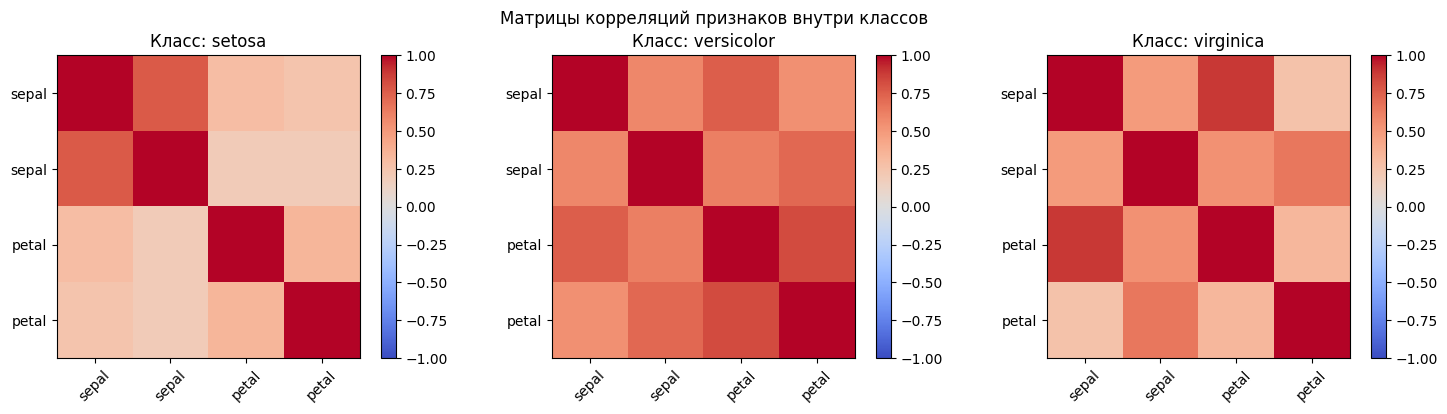

Корреляции для класса setosa:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,0.766,0.289,0.249
sepal width (cm),0.766,1.000,0.189,0.193
petal length (cm),0.289,0.189,1.000,0.342
petal width (cm),0.249,0.193,0.342,1.000


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in range(3):
    X_cls = X_train[y_train == cls]
    corr = X_cls.corr()
    im = axes[cls].imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
    axes[cls].set_title(f"Класс: {data.target_names[cls]}")
    axes[cls].set_xticks(range(4))
    axes[cls].set_yticks(range(4))
    axes[cls].set_xticklabels([f.split(' ')[0] for f in data.feature_names], rotation=45)
    axes[cls].set_yticklabels([f.split(' ')[0] for f in data.feature_names])
    plt.colorbar(im, ax=axes[cls])

plt.suptitle("Матрицы корреляций признаков внутри классов")
plt.tight_layout()
plt.show()

print("Корреляции для класса setosa:")
display(X_train[y_train == 0].corr().round(3))

## Шаг 12. Применение к датасету Breast Cancer и сравнение с LogisticRegression


In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

skLogReg_metrics = pd.read_csv("SkLogReg_metrics.csv").iloc[0].to_dict()

data_cancer = load_breast_cancer()
X_cancer = data_cancer.data
y_cancer = data_cancer.target

print(f"Классы: {data_cancer.target_names}")
print(f"Распределение классов: {np.bincount(y)}")

X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y
)

my_model.fit(X_train_cancer, y_train_cancer)
nb_preds = my_model.predict(X_test_cancer)

nb_metrics = {
    "accuracy": accuracy_score(y_test_cancer, nb_preds),
    "precision": precision_score(y_test_cancer, nb_preds, average='macro', zero_division=0),
    "recall": recall_score(y_test_cancer, nb_preds, average='macro', zero_division=0),
    "f1": f1_score(y_test_cancer, nb_preds, average='macro', zero_division=0),
}

comparison = pd.DataFrame([nb_metrics, skLogReg_metrics], index=["my_NB", "sk_LogReg"])

display(comparison.round(4))

Классы: ['malignant' 'benign']
Распределение классов: [50 50 50]


ValueError: Found input variables with inconsistent numbers of samples: [569, 150]

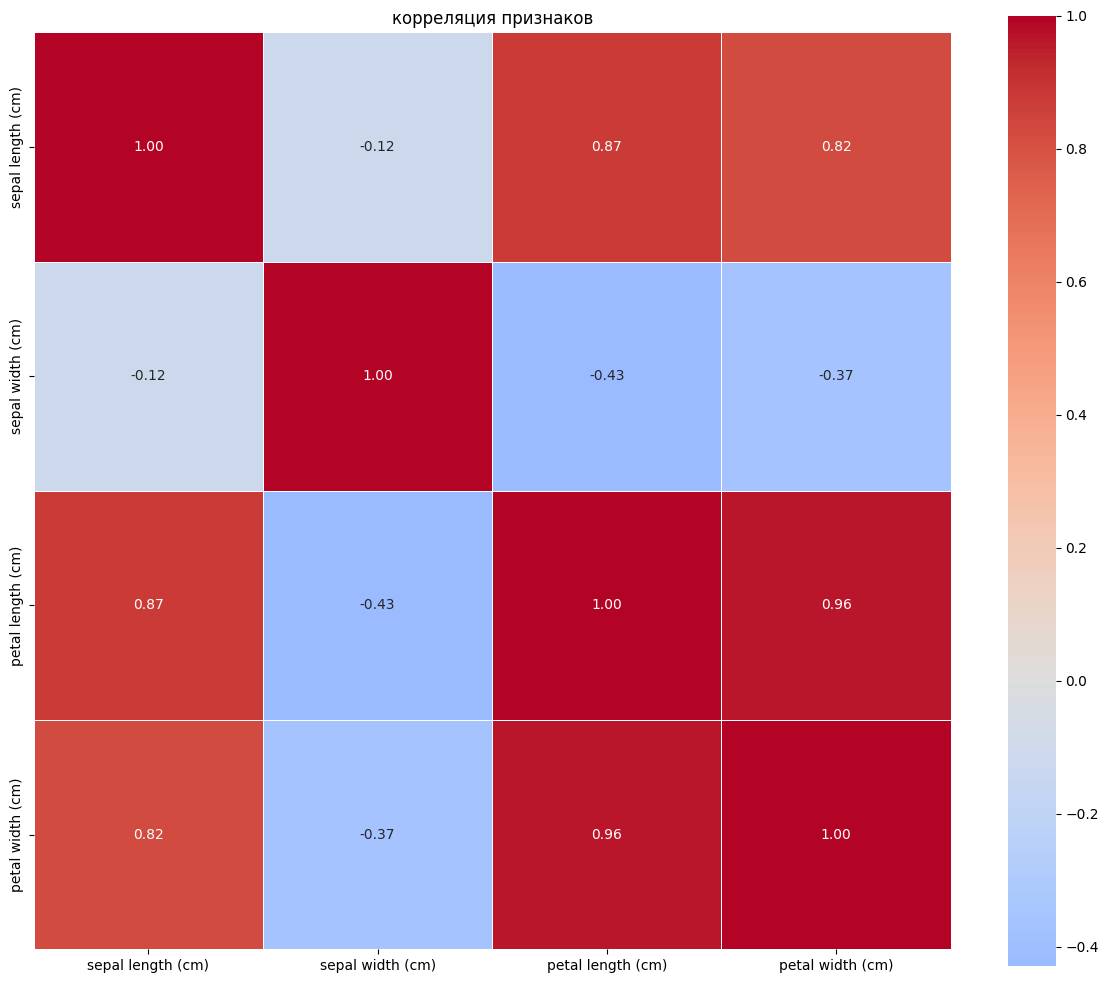

In [ ]:
import seaborn as sns

X_cancer_df = pd.DataFrame(X, columns=data.feature_names)
corr_mat = X_cancer_df.corr()

mean_corr = np.mean(np.abs(corr_mat.values - np.eye(corr_mat.shape[0])))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)

plt.title('корреляция признаков')
plt.tight_layout()
plt.show()

## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. В чём заключается «наивное» допущение Наивного Байеса? Почему его так называют?
2. Почему мы используем логарифм правдоподобия вместо самого правдоподобия?
3. Почему для Гауссовского Наивного Байеса стандартизация данных **не нужна**?
4. Насколько близки метрики вашей реализации к `scikit-learn`? Если есть расхождения — объясните их.
5. Посмотрите на матрицы корреляций: нарушается ли допущение о независимости признаков?
6. Когда Наивный Байес работает хорошо несмотря на нарушение допущения о независимости?
7. Сравните Наивный Байес и Логистическую регрессию: когда предпочесть один метод другому?

-----------
1. Заключается в условной независимости признаков. Называют его "наивным", потому что в реальных данных 
    признаки почти всегда коррелируют
    
2. Для борьбы с underflow: при перемножении множества вероятностей `<1` результат быстро стремится к нулю. 
    Логарифм превращает произведение в сумму, что вычислительно стабильнее и быстрее
    
3. Потому что для каждого признака считаются свои параметры и в формуле плотности каждый признак 
    масштабируется на свою дисперсию

4. Они одинаковые

5. Да, допущение нарушается

6. Если корреляции влияют на все классы примерно одинаково, разделяющая граница остаётся близкой к оптимальной

7. **Наивный Байес** (генеративный): обучается аналитически за `O(N)`, очень быстрый, устойчив к шуму, 
    хорош на   малых выборках и в текстах. Лучше, когда данных мало, нужна скорость или признаки условно независимы.

    **Логистическая регрессия** (дискриминантная): оптимизирует границу напрямую, лучше работает с коррелирующими признаками, но требует итеративной оптимизации и больше данных. Лучше, когда признаки сильно зависимы, важна точность вероятностей или выборка большая
---------

## Дополнительные задания

### Задание A
Добавьте параметр `var_smoothing` в `MyGaussianNB` (аналог `sklearn`): добавляйте к дисперсии небольшую долю от максимальной дисперсии по всем признакам. Посмотрите, как это влияет на метрики.

### Задание B
Попробуйте применить `MyGaussianNB` к датасету `Breast Cancer` (из семинара по логистической регрессии). Сравните качество с логистической регрессией. Объясните разницу.

### Задание C
Реализуйте `predict_proba` — метод, возвращающий нормированные вероятности (не логарифмы). Для этого:
- вычислите `log_proba`,
- вычтите максимум (для численной стабильности),
- примените `exp`,
- нормируйте на сумму.

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- оценка параметров Гауссовского Наивного Байеса с нуля;
- классификация по правилу Байеса;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ допущения о независимости;
- выводы.

Не сдавайте ноутбук без текстовых выводов.